In [3]:
!pip install lightning pytorch-forecasting --quiet
!pip install --upgrade --quiet statsmodels


In [4]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from statsmodels.tsa.seasonal import seasonal_decompose
import torch

import lightning.pytorch as pl
from pytorch_forecasting.metrics import QuantileLoss, MAE
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from lightning.pytorch import Trainer
from pytorch_forecasting import TimeSeriesDataSet
from pytorch_forecasting import TemporalFusionTransformer, Baseline
from lightning.pytorch.loggers import CSVLogger


#Sklearn metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

pd.options.display.float_format = '{:.2f}'.format
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings('ignore')


In [5]:
df=pd.read_csv('Walmart_Sales.csv')
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.57,211.10,8.11
1,1,12-02-2010,1641957.44,1,38.51,2.55,211.24,8.11
2,1,19-02-2010,1611968.17,0,39.93,2.51,211.29,8.11
3,1,26-02-2010,1409727.59,0,46.63,2.56,211.32,8.11
4,1,05-03-2010,1554806.68,0,46.50,2.62,211.35,8.11


In [6]:
df.describe()


,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.00,6435.00,6435.00,6435.00,6435.00,6435.00,6435.00
mean,23.00,1046964.88,0.07,60.66,3.36,171.58,8.00
std,12.99,564366.62,0.26,18.44,0.46,39.36,1.88
min,1.00,209986.25,0.00,-2.06,2.47,126.06,3.88
25%,12.00,553350.10,0.00,47.46,2.93,131.74,6.89
50%,23.00,960746.04,0.00,62.67,3.44,182.62,7.87
75%,34.00,1420158.66,0.00,74.94,3.73,212.74,8.62
max,45.00,3818686.45,1.00,100.14,4.47,227.23,14.31


In [7]:
!pip install --upgrade --quiet ydata_profiling

In [10]:
from ydata_profiling import ProfileReport

profile = ProfileReport(df, title="Walmart Sales Data Profiling Report", explorative=True)
profile.to_file("walmart_sales_data_profiling_report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 8/8 [00:00<00:00, 150.08it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [11]:
# Check the data types of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


**EDA**


In [15]:
duplicates = df.duplicated()

# Duplicates count
print(f"Number of duplicate rows: {duplicates.sum()}")

Number of duplicate rows: 0


In [16]:
df.isnull().sum()


Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

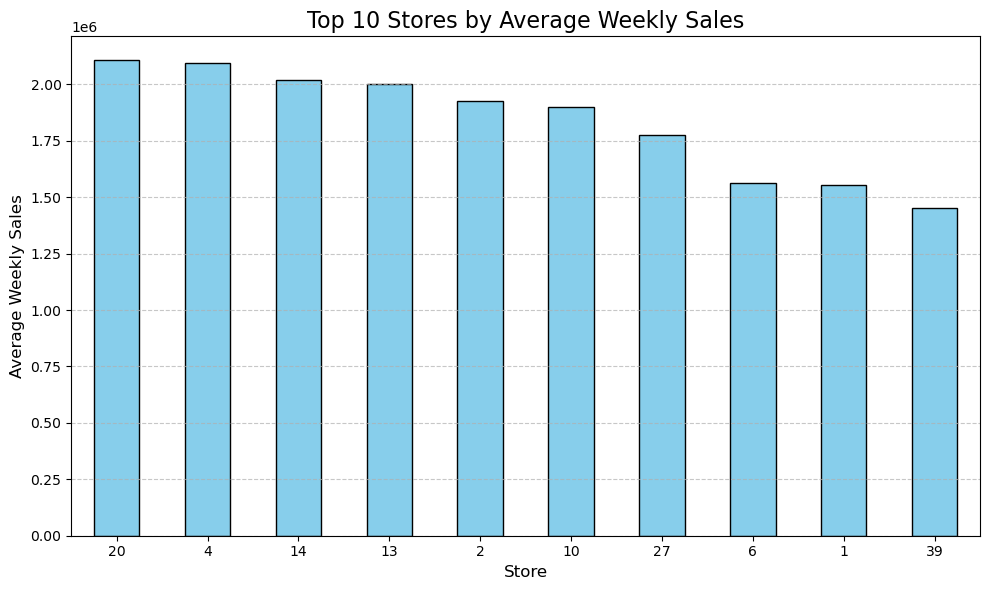

In [22]:
%matplotlib inline

top_stores = df.groupby('Store')['Weekly_Sales'].mean().sort_values(ascending = False)[:10]

#Plot
plt.figure(figsize=(10, 6))
top_stores.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Top 10 Stores by Average Weekly Sales', fontsize=16)
plt.xlabel('Store', fontsize=12)
plt.ylabel('Average Weekly Sales', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

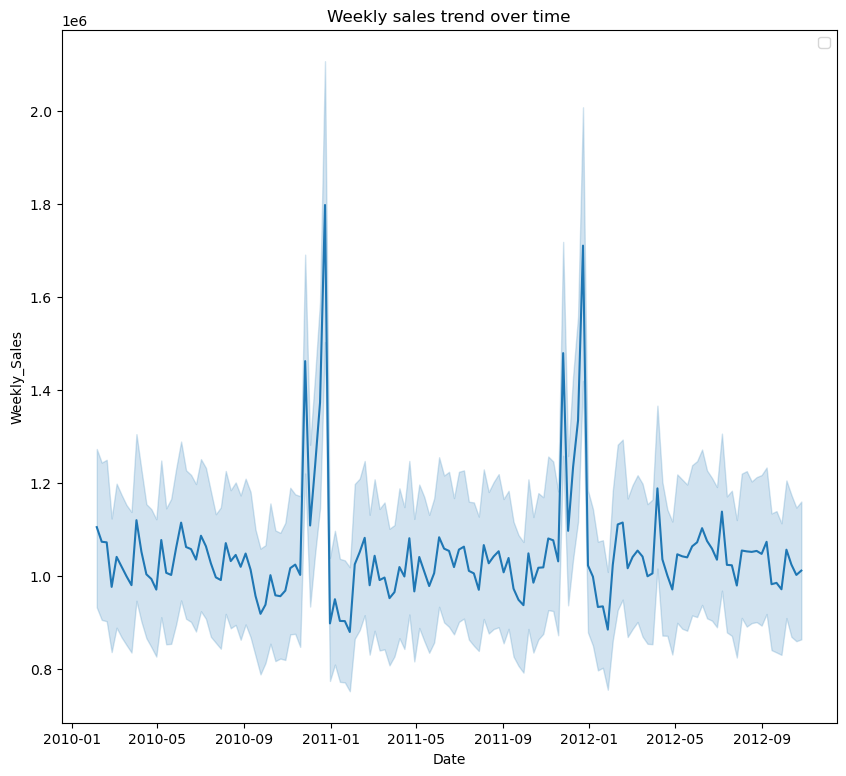

In [23]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst = True)

plt.figure(figsize=(10,9))
sns.lineplot(data = df, x='Date', y="Weekly_Sales")
plt.title("Weekly sales trend over time")
plt.legend()
plt.show()

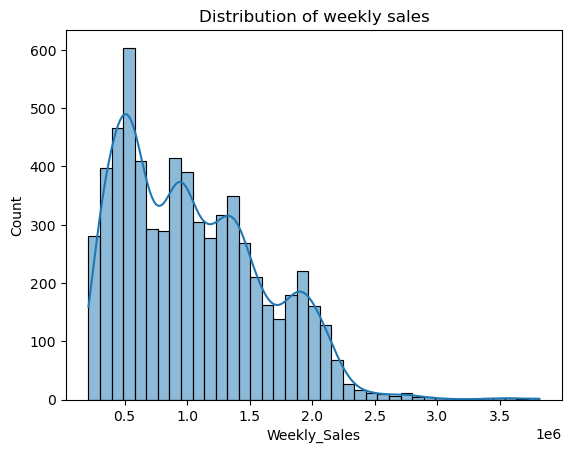

In [24]:
#Distribution of weekly sales
sns.histplot(df['Weekly_Sales'], kde=True)
plt.title('Distribution of weekly sales')
plt.show()

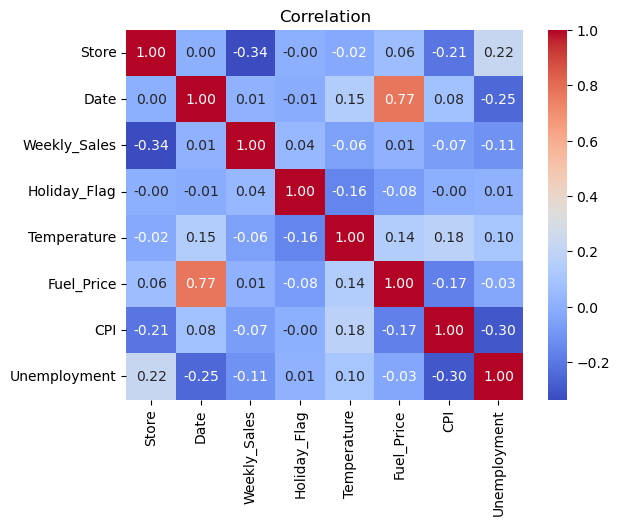

In [25]:
#correlation matrix
corr_matrix = df.corr()
sns.heatmap(corr_matrix,cmap='coolwarm', annot = True, fmt = '.2f')
plt.title("Correlation")
plt.show()

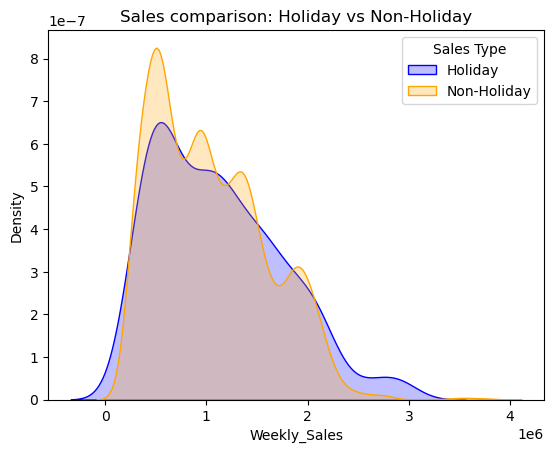

In [26]:
#Holiday impact
holiday_sales = df[df['Holiday_Flag'] == 1]['Weekly_Sales']
non_holiday_sales = df[df['Holiday_Flag'] == 0]['Weekly_Sales']
sns.kdeplot(holiday_sales, label='Holiday', shade=True, color = 'Blue')
sns.kdeplot(non_holiday_sales, label='Non-Holiday', shade=True, color = 'Orange')
plt.legend(title="Sales Type")
plt.title("Sales comparison: Holiday vs Non-Holiday")
plt.show()

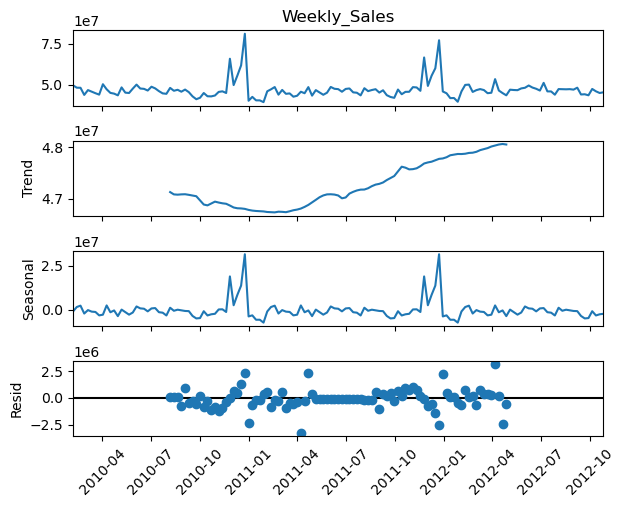

In [27]:
#Seasonal decomposition
decomposition = seasonal_decompose(df.groupby('Date')['Weekly_Sales'].sum(), period=52)
fig = decomposition.plot()
plt.xticks(rotation=45)
plt.show()

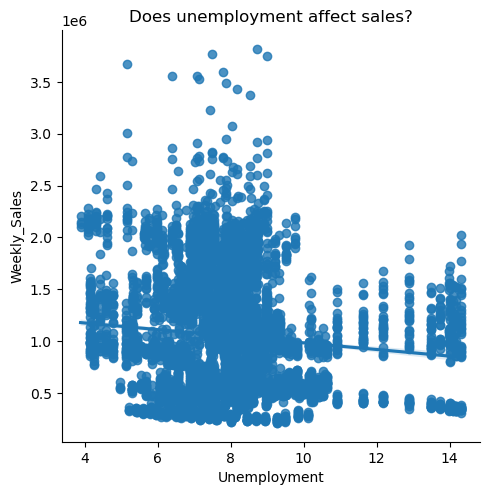

In [32]:
#Impact of unemployment on sales
sns.lmplot(data=df, x='Unemployment', y='Weekly_Sales')
plt.title("Does unemployment affect sales?")
plt.show()

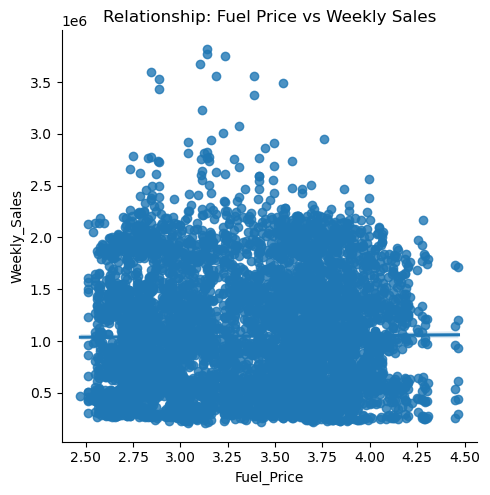

In [33]:
sns.lmplot(data=df, x='Fuel_Price', y='Weekly_Sales')
plt.title("Relationship: Fuel Price vs Weekly Sales")
plt.show()

Correlation between CPI and Weekly Sales: -0.0726


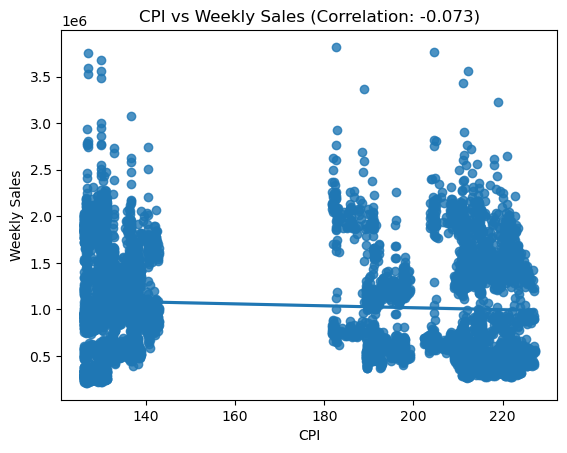

In [35]:
#Effect of CPI on weekly sales
correlation_cpi = df['CPI'].corr(df['Weekly_Sales'])
print(f"Correlation between CPI and Weekly Sales: {correlation_cpi:.4f}")

sns.regplot(data=df, x='CPI', y='Weekly_Sales')
plt.title(f"CPI vs Weekly Sales (Correlation: {correlation_cpi:.3f})")
plt.xlabel('CPI')
plt.ylabel('Weekly Sales')
plt.show()

Feature engineering

In [40]:
#df['Date'] = pd.to_datetime(df['Date'], dayfirst = True)
df["time_idx"] = (df["Date"] - df["Date"].min()).dt.days // 7
df = df.sort_values(["Store", "Date"])
df['Store'] = df['Store'].astype(str)
df['log_Weekly_Sales'] = np.log(df['Weekly_Sales'] + 1)
df['Holiday_Unemployment_Index'] = df['Holiday_Flag'] * df['Unemployment']


In [37]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,time_idx,log_weekly_sales,Holiday_Unemployment_Index
0,1,2010-02-05,1643690.90,0,42.31,2.57,211.10,8.11,0,14.31,0.00
1,1,2010-02-12,1641957.44,1,38.51,2.55,211.24,8.11,1,14.31,8.11
2,1,2010-02-19,1611968.17,0,39.93,2.51,211.29,8.11,2,14.29,0.00
3,1,2010-02-26,1409727.59,0,46.63,2.56,211.32,8.11,3,14.16,0.00
4,1,2010-03-05,1554806.68,0,46.50,2.62,211.35,8.11,4,14.26,0.00


In [38]:
# Params
prediction_length = 5  
encoder_length = 52  
training_cutoff = df["Date"].max() - pd.Timedelta(weeks=prediction_length)  

In [41]:
training = TimeSeriesDataSet(
    df[lambda x: x.Date <= training_cutoff], 
    time_idx="time_idx",  
    target="log_Weekly_Sales", 
    group_ids=["Store"], 
    max_encoder_length = encoder_length,  
    max_prediction_length=prediction_length, 
    time_varying_known_reals = ["time_idx","Holiday_Flag"],  
    time_varying_unknown_reals=["log_Weekly_Sales", "CPI", "Unemployment", "Fuel_Price", "Temperature"], 
    static_categoricals = ["Store"]  
)
#Validation set
validation = TimeSeriesDataSet.from_dataset(
    training, 
    df[df["Date"] > training_cutoff - pd.Timedelta(weeks=encoder_length)],
    predict=True, 
    stop_randomization=True
)


batch_size = 64
train_dataloader = training.to_dataloader(train=True, batch_size = batch_size, num_workers = 3, persistent_workers = True)
val_dataloader = validation.to_dataloader(train=False, batch_size = batch_size, num_workers=3, persistent_workers = True)

In [42]:
loss = QuantileLoss(quantiles=[0.1, 0.5, 0.9])  

#tft model
tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=0.01,               
    hidden_size=32,                   
    attention_head_size=2,             
    dropout=0.3,                       
    loss=loss,                    
    log_interval=10,                  
    reduce_on_plateau_patience=3       
)

In [43]:
# Callbacks
early_stopping_callback = EarlyStopping(
    monitor="val_loss",  
    patience=8,        
    mode="min",         
    verbose=True)

#Best model
checkpoint_callback = ModelCheckpoint(
    monitor="val_loss",  
    filename="best_model-{epoch}-{val_loss:.2f}",
    save_top_k=1,     
    mode="min")

In [44]:
#Logger
log_dir = "working"
csv_logger = CSVLogger(log_dir, name="tft_model")

trainer = Trainer(
    max_epochs=36, 
    accelerator="auto", 
    devices="auto",  
    enable_progress_bar=True,
    gradient_clip_val=0.5,  
    logger=csv_logger,  
    log_every_n_steps=10,
    callbacks=[early_stopping_callback, checkpoint_callback]
)
trainer.fit(
    tft,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │    585 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │    112 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │     96 │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │  7.1 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │  1.9 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  8.4 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  8.4 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │  2.1 K │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     64 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  5.3 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │  3.2 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │  2.2 K │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │  2.2 K │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │     99 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 63.1 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 63.1 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 281                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

Metric val_loss improved. New best score: 0.029


Metric val_loss improved by 0.002 >= min_delta = 0.0. New best score: 0.027


Metric val_loss improved by 0.001 >= min_delta = 0.0. New best score: 0.026


Metric val_loss improved by 0.000 >= min_delta = 0.0. New best score: 0.026


Monitored metric val_loss did not improve in the last 8 records. Best score: 0.026. Signaling Trainer to stop.


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


Validation MAE: 37,932.52
Validation RMSE: 53,172.69


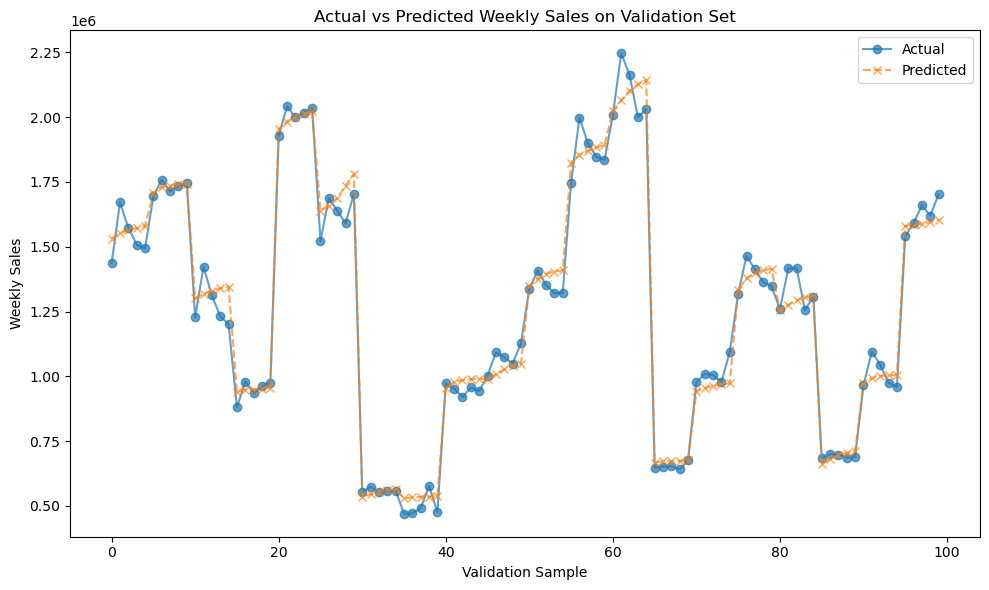

In [47]:
# Evaluate the TFT model on the validation set
best_model = TemporalFusionTransformer.load_from_checkpoint(checkpoint_callback.best_model_path)
predictions = best_model.predict(val_dataloader)

actual_batches = []
for _, y in val_dataloader:
    actual_batches.append(y[0])

actuals = torch.cat(actual_batches, dim=0)

# Convert from log scale back to original Weekly_Sales scale
predictions = np.expm1(predictions.detach().cpu().numpy().reshape(-1))
actuals = np.expm1(actuals.detach().cpu().numpy().reshape(-1))

mae = mean_absolute_error(actuals, predictions)
rmse = np.sqrt(mean_squared_error(actuals, predictions))

print(f"Validation MAE: {mae:,.2f}")
print(f"Validation RMSE: {rmse:,.2f}")

plt.figure(figsize=(10, 6))
plt.plot(actuals[:100], label='Actual', marker='o', linestyle='-', alpha=0.7)
plt.plot(predictions[:100], label='Predicted', marker='x', linestyle='--', alpha=0.7)
plt.title('Actual vs Predicted Weekly Sales on Validation Set')
plt.xlabel('Validation Sample')
plt.ylabel('Weekly Sales')
plt.legend()
plt.tight_layout()
plt.show()